# Random Forest — Diagnostics

A data-science investigation of the main Random Forest model (`src/models/rf.py`) **before**
hyperparameter tuning. The walk-forward backtest has the RF trailing the Elo baseline:

| Model | Log loss | Brier |
|---|---|---|
| baseline_elo | 1.0159 | 0.6089 |
| rf | 1.0324 | 0.6189 |
| log_reg | 1.0807 | 0.6396 |

Goal: *understand where the RF is going wrong* using visuals, and turn that into concrete
hypotheses for the tuning and calibration stories. This notebook is scratch exploration — it
reads the real backtest outputs and changes no model and no pipeline code.

Working hypotheses to test below:
1. With `max_depth=None` the forest grows fully and produces **overconfident** probabilities
   (which log loss / Brier punish).
2. With draws only ~26% of matches, the RF **under-predicts draws**.


In [1]:
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.calibration import calibration_curve
from sklearn.model_selection import TimeSeriesSplit

# Make the project root importable (this notebook lives in notebooks/)
ROOT = Path.cwd()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.features.build_features import build_features

# Shared conventions (match notebooks/02_logreg_eda.ipynb)
LABEL_ORDER = ["HW", "D", "AW"]
LABEL_NAMES = {"HW": "Home win", "D": "Draw", "AW": "Away win"}
PALETTE = {"HW": "#2a9d8f", "D": "#e9c46a", "AW": "#e76f51"}
PROB_COLS = ["p_home", "p_draw", "p_away"]
CLASS_IDX = {l: i for i, l in enumerate(LABEL_ORDER)}

# Load the real backtest outputs produced by src/backtest/walk_forward.py
preds = pd.read_parquet(ROOT / "reports" / "predictions.parquet")
metrics = pd.read_csv(ROOT / "reports" / "metrics.csv")
importances = json.loads((ROOT / "artifacts" / "feature_importances.json").read_text())


# Backtest rows for one model (probs already in [HW, D, AW] order).
def model_slice(name):
    return preds[preds["model"] == name].reset_index(drop=True)


rf = model_slice("rf")
elo = model_slice("baseline_elo")

print("Models in backtest:", preds["model"].unique().tolist())
print("RF backtested matches:", len(rf))
metrics[metrics["fold"] == "overall"].sort_values("log_loss")


Models in backtest: ['baseline_elo', 'log_reg', 'rf']
RF backtested matches: 760


            model     fold    n  log_loss     brier
76   baseline_elo  overall  760  1.015937  0.608918
230            rf  overall  760  1.032420  0.618905
153       log_reg  overall  760  1.080691  0.639570

## 1. Class balance — the bar to beat
Base rates frame everything: home wins dominate and draws are the minority, so a model that never predicts draws can still look 'accurate'.

y_true
HW    0.417
D     0.259
AW    0.324
Name: count, dtype: float64


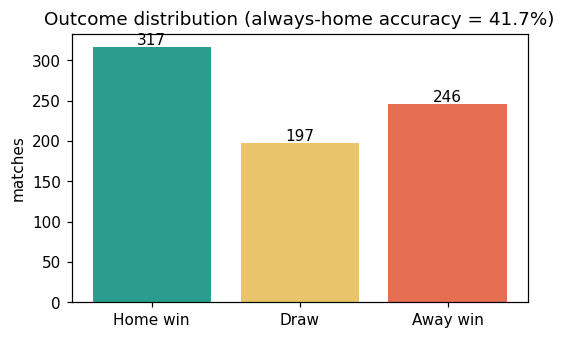

In [2]:
counts = rf["y_true"].value_counts().reindex(LABEL_ORDER)
props = (counts / counts.sum()).round(3)
print(props)

fig, ax = plt.subplots(figsize=(5, 3.2))
ax.bar([LABEL_NAMES[l] for l in LABEL_ORDER], counts.values,
       color=[PALETTE[l] for l in LABEL_ORDER])
ax.set_ylabel("matches")
ax.set_title("Outcome distribution (always-home accuracy = %.1f%%)" % (props["HW"] * 100))
for i, v in enumerate(counts.values):
    ax.text(i, v + 3, str(v), ha="center")
plt.tight_layout(); plt.show()


## 2. Feature importances
Which features the RF leans on. If the Elo block dominates, that explains why the RF only matches the Elo baseline — and informs whether the other features are pulling their weight.

Elo features account for 21.5% of total importance.
Top 5:
 elo_diff                0.0938
home_position_diff      0.0679
elo_home_pre            0.0637
elo_away_pre            0.0572
home_league_position    0.0394


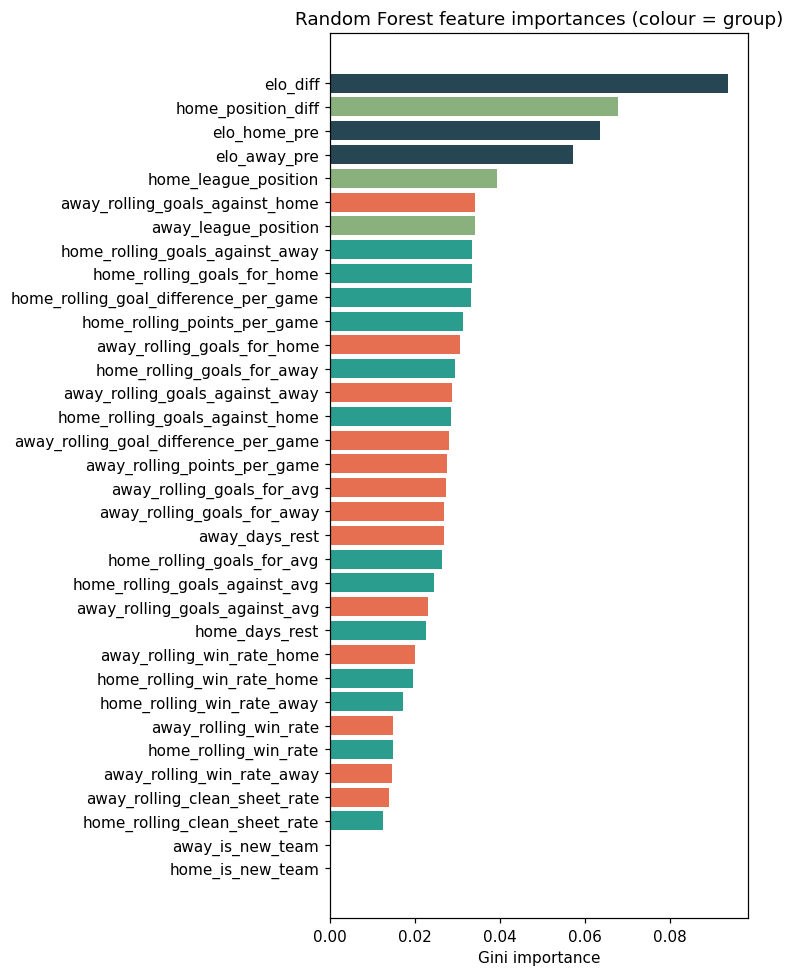

In [3]:
def group_color(name):
    if name.startswith("elo"):
        return "#264653"
    if "position" in name:
        return "#8ab17d"
    if name.startswith("home"):
        return PALETTE["HW"]
    if name.startswith("away"):
        return PALETTE["AW"]
    return "#999999"

imp = pd.Series(importances).sort_values()  # ascending so the largest sit on top in barh

fig, ax = plt.subplots(figsize=(7, 9))
ax.barh(imp.index, imp.values, color=[group_color(n) for n in imp.index])
ax.set_xlabel("Gini importance")
ax.set_title("Random Forest feature importances (colour = group)")
plt.tight_layout(); plt.show()

elo_share = sum(v for k, v in importances.items() if k.startswith("elo"))
print(f"Elo features account for {elo_share:.1%} of total importance.")
print("Top 5:\n", pd.Series(importances).sort_values(ascending=False).head(5).round(4).to_string())


## 3. Confusion matrix (3-class)
Argmax predictions from the walk-forward backtest vs actual outcomes. The row-normalised view is per-class recall — watch the Draw row.

Draws predicted: 13 of 197 actual draws
Confusion matrix total: 760


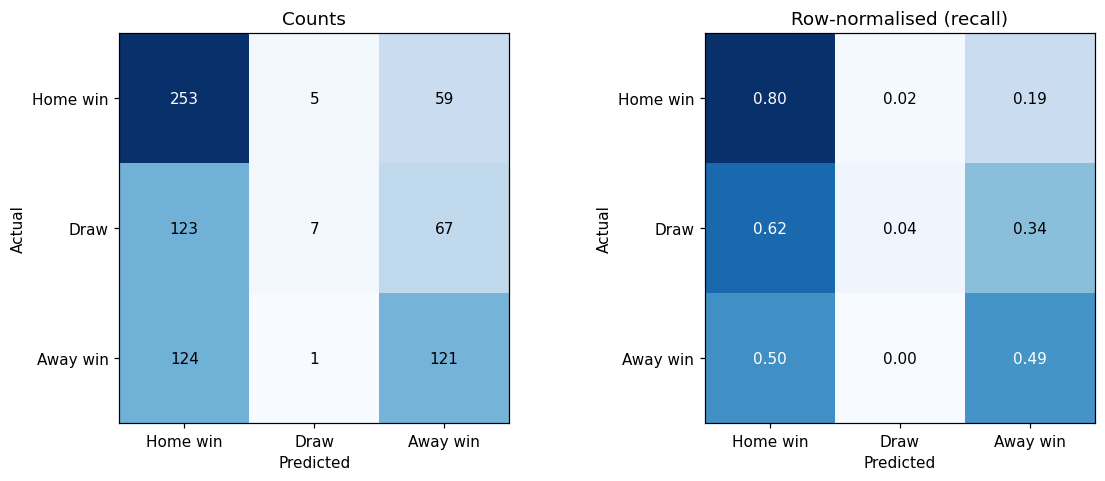

In [4]:
y_true = rf["y_true"].to_numpy()
y_pred = np.array(LABEL_ORDER)[rf[PROB_COLS].to_numpy().argmax(axis=1)]

cm = confusion_matrix(y_true, y_pred, labels=LABEL_ORDER)
cm_norm = cm / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, mat, title, fmt in [
    (axes[0], cm, "Counts", "d"),
    (axes[1], cm_norm, "Row-normalised (recall)", ".2f"),
]:
    im = ax.imshow(mat, cmap="Blues")
    ax.set_xticks(range(3)); ax.set_xticklabels([LABEL_NAMES[l] for l in LABEL_ORDER])
    ax.set_yticks(range(3)); ax.set_yticklabels([LABEL_NAMES[l] for l in LABEL_ORDER])
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual"); ax.set_title(title)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, format(mat[i, j], fmt), ha="center", va="center",
                    color="white" if mat[i, j] > mat.max() * 0.6 else "black")
plt.tight_layout(); plt.show()

print("Draws predicted:", int((y_pred == "D").sum()), "of", int((y_true == "D").sum()), "actual draws")
print("Confusion matrix total:", int(cm.sum()))


## 4. Classification report
Per-class precision / recall / F1. Draw recall is the number to watch — a confidently low value confirms the model rarely backs a draw.

              precision  recall  f1-score  support
Home win          0.506   0.798     0.619  317.000
Draw              0.538   0.036     0.067  197.000
Away win          0.490   0.492     0.491  246.000
accuracy          0.501   0.501     0.501    0.501
macro avg         0.511   0.442     0.392  760.000
weighted avg      0.509   0.501     0.434  760.000


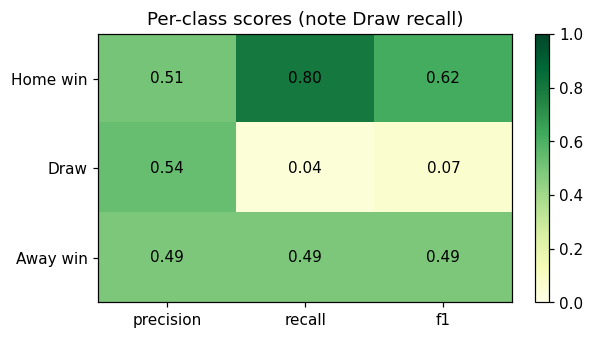

In [5]:
rep = classification_report(
    y_true, y_pred, labels=LABEL_ORDER,
    target_names=[LABEL_NAMES[l] for l in LABEL_ORDER],
    output_dict=True, zero_division=0,
)
rep_df = pd.DataFrame(rep).T
print(rep_df.round(3).to_string())

cls = rep_df.loc[[LABEL_NAMES[l] for l in LABEL_ORDER], ["precision", "recall", "f1-score"]]
fig, ax = plt.subplots(figsize=(5.5, 3.2))
im = ax.imshow(cls.values.astype(float), cmap="YlGn", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(3)); ax.set_xticklabels(["precision", "recall", "f1"])
ax.set_yticks(range(3)); ax.set_yticklabels(cls.index)
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{cls.values[i, j]:.2f}", ha="center", va="center")
ax.set_title("Per-class scores (note Draw recall)")
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()


## 5. Probability behaviour — is the RF overconfident?
Log loss punishes confident mistakes. Here we compare how the RF spreads its probabilities vs the smoother Elo baseline. If RF pushes mass toward the extremes, that is the likely cause of its worse log loss.

Mean confidence  RF: 0.531   Elo: 0.530


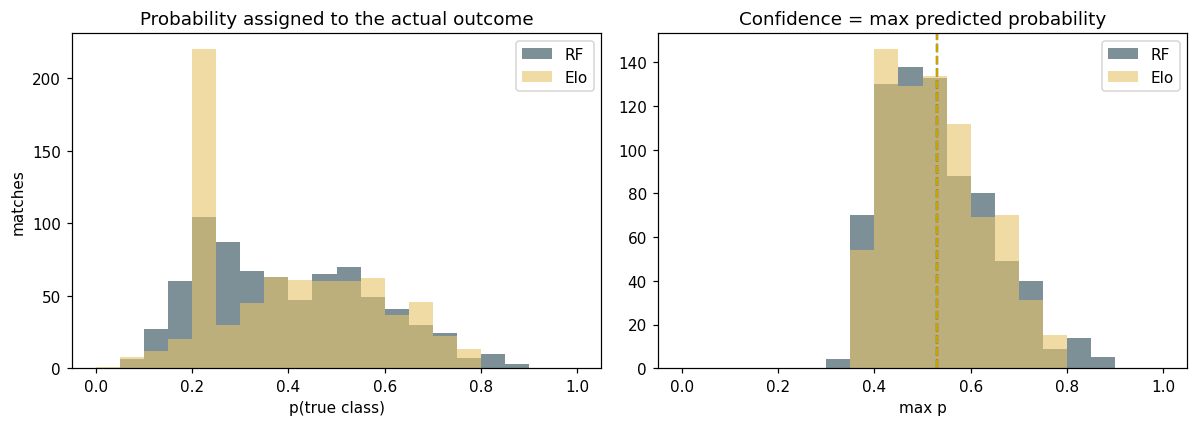

In [6]:
def true_class_prob(df):
    yi = df["y_true"].map(CLASS_IDX).to_numpy()
    P = df[PROB_COLS].to_numpy()
    return P[np.arange(len(P)), yi]


def max_prob(df):
    return df[PROB_COLS].to_numpy().max(axis=1)

bins = np.linspace(0, 1, 21)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(true_class_prob(rf), bins=bins, alpha=0.6, label="RF", color="#264653")
axes[0].hist(true_class_prob(elo), bins=bins, alpha=0.6, label="Elo", color="#e9c46a")
axes[0].set_title("Probability assigned to the actual outcome")
axes[0].set_xlabel("p(true class)"); axes[0].set_ylabel("matches"); axes[0].legend()

axes[1].hist(max_prob(rf), bins=bins, alpha=0.6, label="RF", color="#264653")
axes[1].hist(max_prob(elo), bins=bins, alpha=0.6, label="Elo", color="#e9c46a")
axes[1].axvline(max_prob(rf).mean(), color="#264653", ls="--")
axes[1].axvline(max_prob(elo).mean(), color="#caa300", ls="--")
axes[1].set_title("Confidence = max predicted probability")
axes[1].set_xlabel("max p"); axes[1].legend()
plt.tight_layout(); plt.show()

print(f"Mean confidence  RF: {max_prob(rf).mean():.3f}   Elo: {max_prob(elo).mean():.3f}")


## 6. Reliability diagrams (calibration curves)
For each outcome (one-vs-rest), how predicted probability compares to observed frequency. Points below the diagonal = overconfident. This is the *evidence* for the separate calibration story (which will produce the real `reports/calibration_curve.png`).

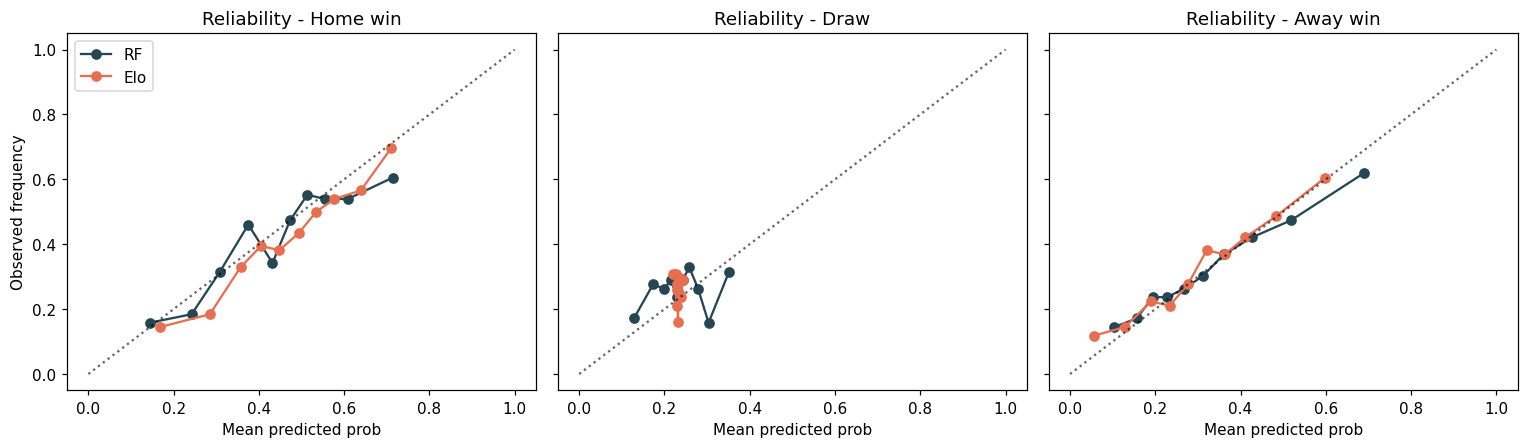

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), sharey=True)
for ax, label, col in zip(axes, LABEL_ORDER, PROB_COLS):
    for df, name, color in [(rf, "RF", "#264653"), (elo, "Elo", "#e76f51")]:
        y_bin = (df["y_true"] == label).astype(int).to_numpy()
        frac_pos, mean_pred = calibration_curve(
            y_bin, df[col].to_numpy(), n_bins=10, strategy="quantile"
        )
        ax.plot(mean_pred, frac_pos, "o-", label=name, color=color)
    ax.plot([0, 1], [0, 1], "k:", alpha=0.6)
    ax.set_title(f"Reliability - {LABEL_NAMES[label]}")
    ax.set_xlabel("Mean predicted prob")
axes[0].set_ylabel("Observed frequency"); axes[0].legend()
plt.tight_layout(); plt.show()


## 7. Per-fold log loss across TimeSeriesSplit(5)
Mirrors the CV scheme the tuning story will use. We sort chronologically, then fit and score all three models on each fold — the pre-tuning baseline the tuned RF will later be overlaid onto.

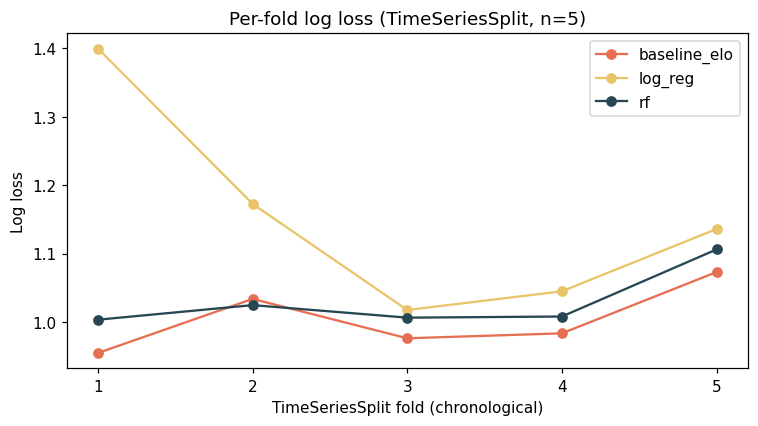

       baseline_elo  log_reg      rf
fold1        0.9548   1.3995  1.0035
fold2        1.0338   1.1726  1.0247
fold3        0.9763   1.0176  1.0064
fold4        0.9835   1.0450  1.0081
fold5        1.0731   1.1360  1.1061
mean         1.0043   1.1541  1.0298

In [8]:
from src.backtest.walk_forward import (
    elo_backtest_model,
    log_reg_backtest_model,
    rf_backtest_model,
)

# Rebuild X/y/meta and sort by (date, match_id) so TimeSeriesSplit respects chronology.
X, y, meta = build_features(save_schema=False)
order = np.argsort(meta[["date", "match_id"]].apply(tuple, axis=1).to_numpy(), kind="stable")
X = X.iloc[order].reset_index(drop=True)
y = y.iloc[order].reset_index(drop=True)

tss = TimeSeriesSplit(n_splits=5)
models = [elo_backtest_model(), log_reg_backtest_model(), rf_backtest_model()]
colors = {"baseline_elo": "#e76f51", "log_reg": "#e9c46a", "rf": "#264653"}
results = {m.name: [] for m in models}

for tr, te in tss.split(X):
    yi = y.iloc[te].map(CLASS_IDX).to_numpy()
    for m in models:
        state = m.fit(X.iloc[tr], y.iloc[tr])
        P = m.predict_proba(state, X.iloc[te])
        ll = -np.mean(np.log(np.clip(P[np.arange(len(P)), yi], 1e-15, None)))
        results[m.name].append(ll)

folds = list(range(1, tss.n_splits + 1))
fig, ax = plt.subplots(figsize=(7, 4))
for name, lls in results.items():
    ax.plot(folds, lls, "o-", label=name, color=colors[name])
ax.set_xlabel("TimeSeriesSplit fold (chronological)")
ax.set_ylabel("Log loss"); ax.set_title("Per-fold log loss (TimeSeriesSplit, n=5)")
ax.set_xticks(folds); ax.legend()
plt.tight_layout(); plt.show()

cv_df = pd.DataFrame(results, index=[f"fold{i}" for i in folds])
cv_df.loc["mean"] = cv_df.mean()
cv_df.round(4)


## 8. Log loss vs `max_depth`
Does limiting tree depth help? We sweep `max_depth` from 3 to 20, averaging log loss over the same `TimeSeriesSplit(5)` folds (leakage-safe, `X`/`y` already date-sorted in section 7). The dashed line is the current default (`max_depth=None`, fully grown). A dip below it would justify capping depth in the tuning story.

Best depth: 4 -> log loss 1.0225
Default (max_depth=None): 1.0298


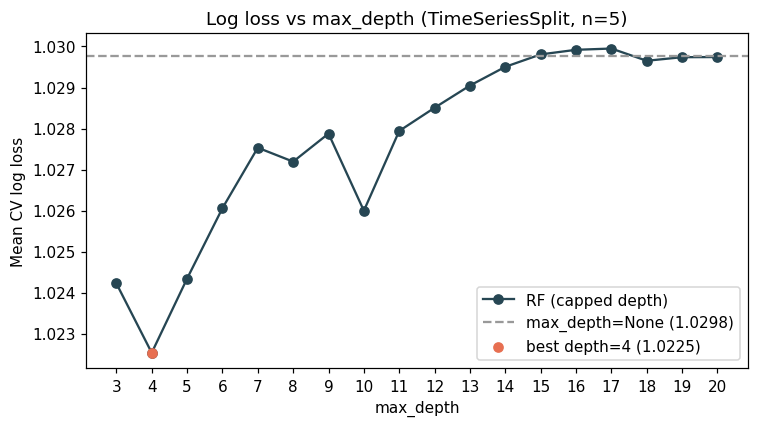

In [9]:
from src.models.rf import train_rf, predict_proba as rf_predict_proba

# Mean CV log loss for a given RF param dict, over the same TimeSeriesSplit folds as above.
def cv_logloss(params):
    fold_ll = []
    for tr, te in tss.split(X):
        model = train_rf(X.iloc[tr], y.iloc[tr], params=params)
        P = rf_predict_proba(model, X.iloc[te])
        yi = y.iloc[te].map(CLASS_IDX).to_numpy()
        fold_ll.append(-np.mean(np.log(np.clip(P[np.arange(len(P)), yi], 1e-15, None))))
    return float(np.mean(fold_ll))

depths = list(range(3, 21))
depth_ll = [cv_logloss({"max_depth": d}) for d in depths]
default_ll = cv_logloss({"max_depth": None})  # current default (fully grown trees)
best_i = int(np.argmin(depth_ll))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(depths, depth_ll, "o-", color="#264653", label="RF (capped depth)")
ax.axhline(default_ll, color="#999999", ls="--", label=f"max_depth=None ({default_ll:.4f})")
ax.scatter([depths[best_i]], [depth_ll[best_i]], color="#e76f51", zorder=5,
           label=f"best depth={depths[best_i]} ({depth_ll[best_i]:.4f})")
ax.set_xlabel("max_depth"); ax.set_ylabel("Mean CV log loss")
ax.set_title("Log loss vs max_depth (TimeSeriesSplit, n=5)")
ax.set_xticks(depths); ax.legend()
plt.tight_layout(); plt.show()

print(f"Best depth: {depths[best_i]} -> log loss {depth_ll[best_i]:.4f}")
print(f"Default (max_depth=None): {default_ll:.4f}")


## 9. Summary & hypotheses for the next stories

*(Fill in after reading the figures above — placeholder read-out based on the working hypotheses.)*

- **Overconfidence:** if the RF confidence histogram sits further right than Elo and its
  reliability points fall below the diagonal, the RF is over-sure. → **Tuning story:** cap
  `max_depth` and raise `min_samples_leaf` to soften leaf probabilities. → **Calibration
  story:** apply calibration to pull probabilities back onto the diagonal.
- **Draw blindness:** if Draw recall is near zero, the model almost never backs a draw — an
  inherent 3-way-football problem, useful context for interpreting accuracy.
- **Feature reliance:** if the Elo block holds most of the importance, the extra features add
  little for the RF — evidence to weigh in the (separate) feature-trim decision; no schema
  change is made here.
- **Fold stability:** the TimeSeriesSplit panel shows whether RF trails Elo consistently or
  only in certain periods.

No model or schema changes are made in this notebook — these are inputs to the tuning and
calibration stories.
